In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/diploma_cv_cherry'
SAVE_PATH = '/content/drive/MyDrive/best_cherry_model.pth'

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from tqdm import tqdm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Работаем на: cuda


In [ ]:

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=DATA_PATH, transform=base_transform)

for class_name, index in dataset.class_to_idx.items():
    print(f"Папка '{class_name}' -> Индекс {index}")

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

n_total = len(dataset)
n_train = int(0.82 * n_total)
n_val = int(0.08 * n_total)
n_test = n_total - n_train - n_val

train_subset, val_subset, test_subset = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print(f"\nВсего: {n_total} | Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_subset)}")

--- Соответствие классов индексам ---
Папка 'overripe' -> Индекс 0
Папка 'ripe' -> Индекс 1
Папка 'unripe' -> Индекс 2

Всего: 252 | Train: 206 | Val: 20 | Test: 26


In [ ]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 3)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 178MB/s]


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    best_acc = 0.0

    for epoch in range(epochs):
        print(f'\nЭпоха {epoch+1}/{epochs}')
        model.train()
        running_loss = 0.0
        train_corrects = 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            train_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_subset)
        epoch_acc = train_corrects.double() / len(train_subset)
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        model.eval()
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)

        val_acc = val_corrects.double() / len(val_subset)
        print(f'Val Acc: {val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)

train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15)


Эпоха 1/15


Training: 100%|██████████| 7/7 [02:03<00:00, 17.61s/it]


Train Loss: 0.7751 Acc: 0.6650
Val Acc: 0.9000
✓ Новая лучшая модель сохранена (Acc: 0.9000)

Эпоха 2/15


Training: 100%|██████████| 7/7 [00:27<00:00,  3.97s/it]


Train Loss: 0.1516 Acc: 0.9612
Val Acc: 1.0000
✓ Новая лучшая модель сохранена (Acc: 1.0000)

Эпоха 3/15


Training: 100%|██████████| 7/7 [00:28<00:00,  4.13s/it]


Train Loss: 0.0363 Acc: 0.9903
Val Acc: 1.0000

Эпоха 4/15


Training:  71%|███████▏  | 5/7 [00:24<00:09,  4.85s/it]


KeyboardInterrupt: 

In [ ]:
def evaluate_model(model, test_loader):
    model.load_state_dict(torch.load(SAVE_PATH))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nОтчет о классификации:")
    print(classification_report(all_labels, all_preds, target_names=list(idx_to_class.values())))

    print("Матрица ошибок (Confusion Matrix):")
    print(confusion_matrix(all_labels, all_preds))

evaluate_model(model, test_loader)


Отчет о классификации:
              precision    recall  f1-score   support

    overripe       1.00      0.90      0.95        10
        ripe       0.92      1.00      0.96        12
      unripe       1.00      1.00      1.00         4

    accuracy                           0.96        26
   macro avg       0.97      0.97      0.97        26
weighted avg       0.96      0.96      0.96        26

Матрица ошибок (Confusion Matrix):
[[ 9  1  0]
 [ 0 12  0]
 [ 0  0  4]]


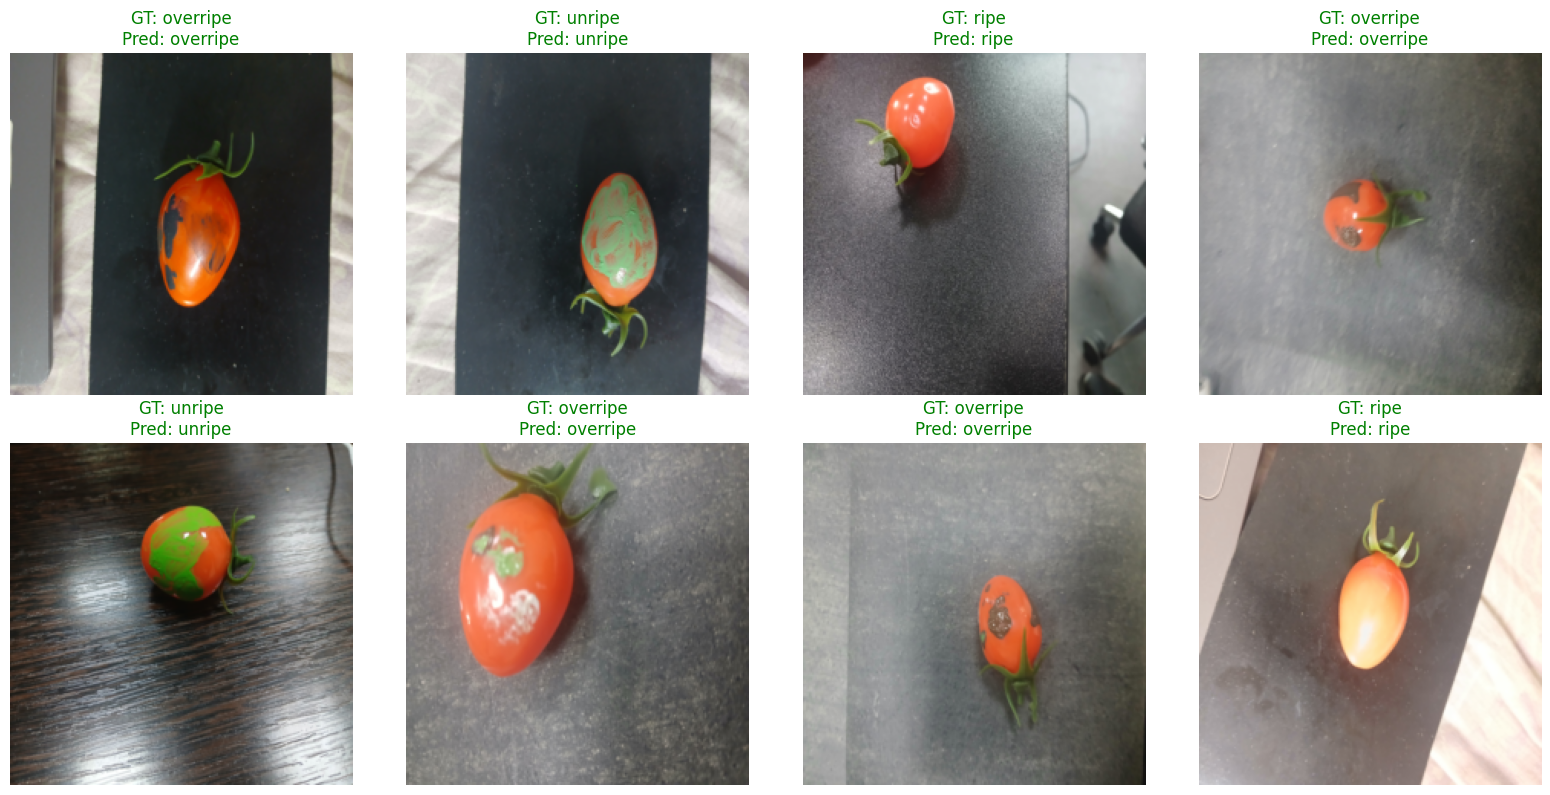

In [ ]:
import matplotlib.pyplot as plt

def visualize_test_results(model, test_loader, num_images=8):
    if os.path.exists(SAVE_PATH):
        model.load_state_dict(torch.load(SAVE_PATH))
    model.eval()

    images_handled = 0
    plt.figure(figsize=(16, 8))

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_handled += 1
                ax = plt.subplot(num_images // 4, 4, images_handled)
                ax.axis('off')
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                is_correct = preds[j] == labels[j]
                color = 'green' if is_correct else 'red'

                plt.imshow(img)
                ax.set_title(f'GT: {idx_to_class[labels[j].item()]}\nPred: {idx_to_class[preds[j].item()]}',
                             color=color, fontsize=12)

                if images_handled == num_images:
                    return

visualize_test_results(model, test_loader)
plt.tight_layout()
plt.show()

Загрузите изображение для классификации:


Saving Gemini_Generated_Image_didy6cdidy6cdidy.png to Gemini_Generated_Image_didy6cdidy6cdidy.png


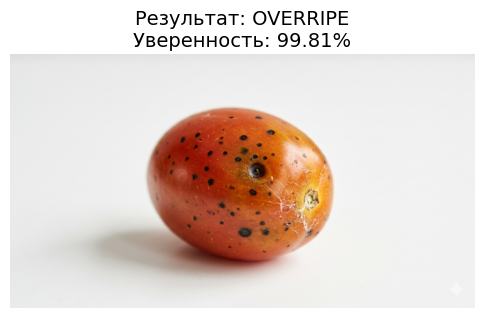

Распределение вероятностей:
- overripe: 99.81%
- ripe: 0.18%
- unripe: 0.01%


In [ ]:
from google.colab import files
from PIL import Image
import io

def predict_external_image(model, idx_to_class):
    if not os.path.exists(SAVE_PATH):
        print("Ошибка: Файл модели не найден. Сначала заверши обучение.")
        return

    model.load_state_dict(torch.load(SAVE_PATH))
    model.eval()
    print("Загрузите изображение для классификации:")
    uploaded = files.upload()

    if not uploaded:
        return

    filename = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    input_tensor = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.nn.functional.softmax(outputs[0], dim=0)
        conf, preds = torch.max(outputs, 1)

    label = idx_to_class[preds.item()]
    score = probs[preds.item()].item() * 100

    # Вывод результата
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Результат: {label.upper()}\nУверенность: {score:.2f}%', fontsize=14)
    plt.show()

    print(f"Распределение вероятностей:")
    for i in range(len(idx_to_class)):
        print(f"- {idx_to_class[i]}: {probs[i].item()*100:.2f}%")

predict_external_image(model, idx_to_class)